<a href="https://colab.research.google.com/github/Pranayshukla0610/Data-Science-Projects/blob/main/AI_Interior_Design_Generator_using_Latent_Diffusion_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install diffusers transformers accelerate safetensors torch torchvision pillow opencv-python -q

In [2]:
import torch
from diffusers import StableDiffusionImg2ImgPipeline
from PIL import Image
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
print("CUDA Available:",torch.cuda.is_available())

CUDA Available: True


In [4]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id,
    torch_dtype = torch.float16
)

pipe = pipe.to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
from google.colab import files
uploaded = files.upload()

Saving pexels-curtis-adams-11125424.jpg to pexels-curtis-adams-11125424.jpg


In [6]:
init_image = Image.open("/content/pexels-curtis-adams-11125424.jpg").convert("RGB")
print(init_image.size)

(4000, 2668)


In [7]:
init_image = init_image.resize((512,512))

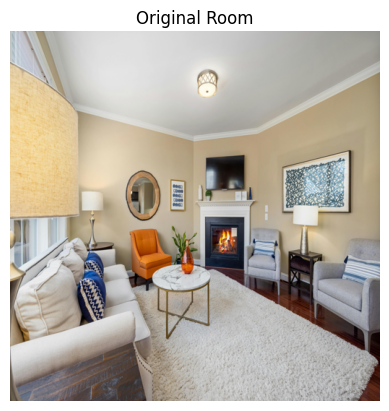

In [8]:
plt.imshow(init_image)
plt.axis('off')
plt.title('Original Room')
plt.show()

In [9]:
prompt = """
Modern luxury living room interior,
wooden flooring,
warm lighting,
minimalistic furniture,
high quality interior design,
architectural digest style,
ultra realistic,
4k
"""

In [10]:
negative_prompt = """
low quality,
blurry,
distorted furniture,
bad architecture,
crooked walls,
poor lighting
"""

In [11]:
result = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.75,
    guidance_scale=8.5,
    negative_prompt = negative_prompt,
    num_inference_steps=40
).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

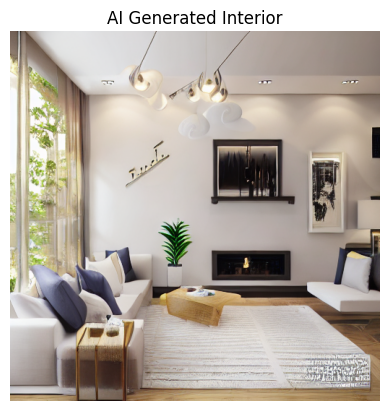

In [12]:
plt.imshow(result)
plt.axis('off')
plt.title('AI Generated Interior')
plt.show()

In [13]:
result.save("ai_interior_design.png")

print("Interior design generated successfully!")

Interior design generated successfully!
